C:\Users\prava\AppData\Local\Temp\ipykernel_10488\967766832.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('prognosis').apply(lambda x: x.sample(desired_rows_per_class, random_state=42)).reset_index(drop=True)
C:\Users\prava\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\prava\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: Undefined

Model: SVC
Accuracy: 1.0000
Classification Report:
                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00         4
                                   AIDS       1.00      1.00      1.00         5
                                   Acne       1.00      1.00      1.00         4
                    Alcoholic hepatitis       1.00      1.00      1.00         4
                                Allergy       1.00      1.00      1.00         3
                              Arthritis       1.00      1.00      1.00         2
                       Bronchial Asthma       1.00      1.00      1.00         3
                   Cervical spondylosis       1.00      1.00      1.00         1
                            Chicken pox       1.00      1.00      1.00         4
                    Chronic cholestasis       1.00      1.00      1.00         6
                            Common Cold       1.00      1

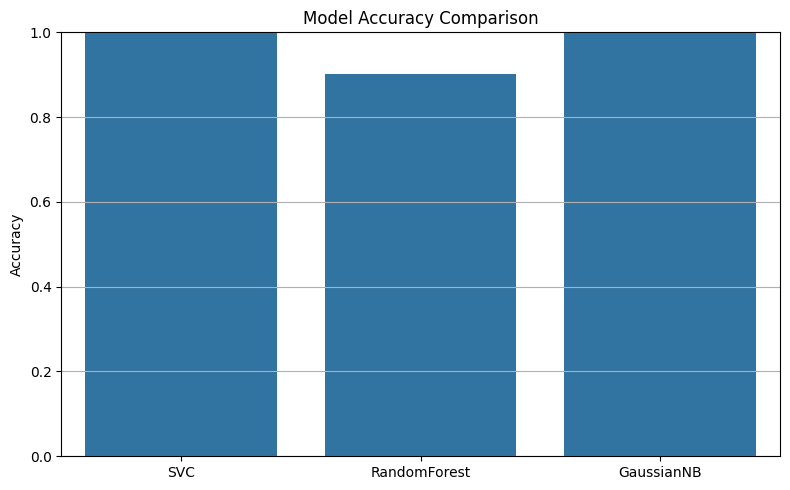

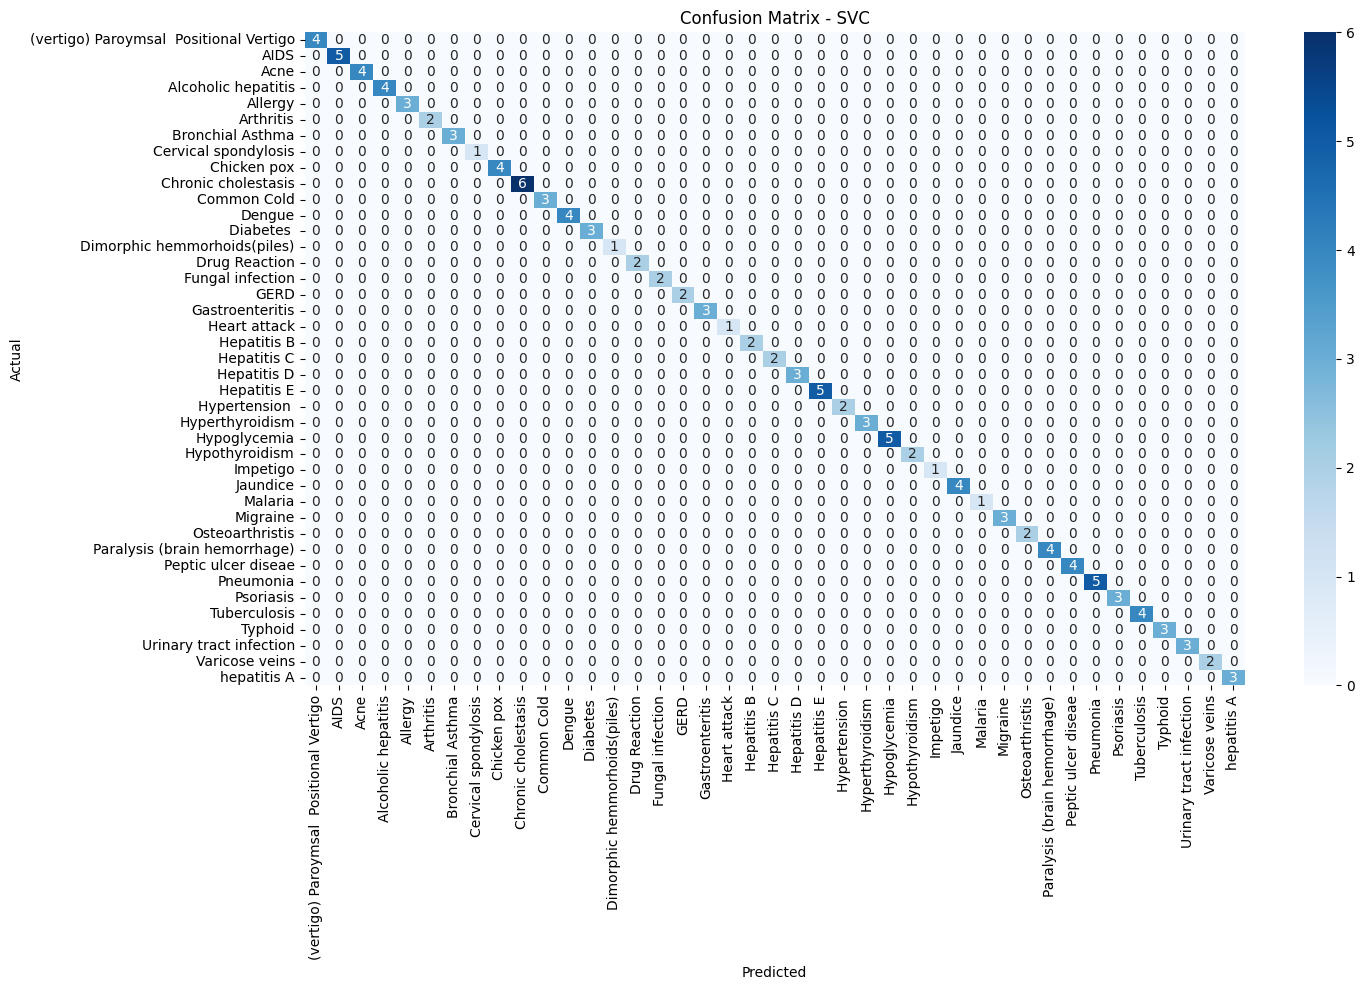

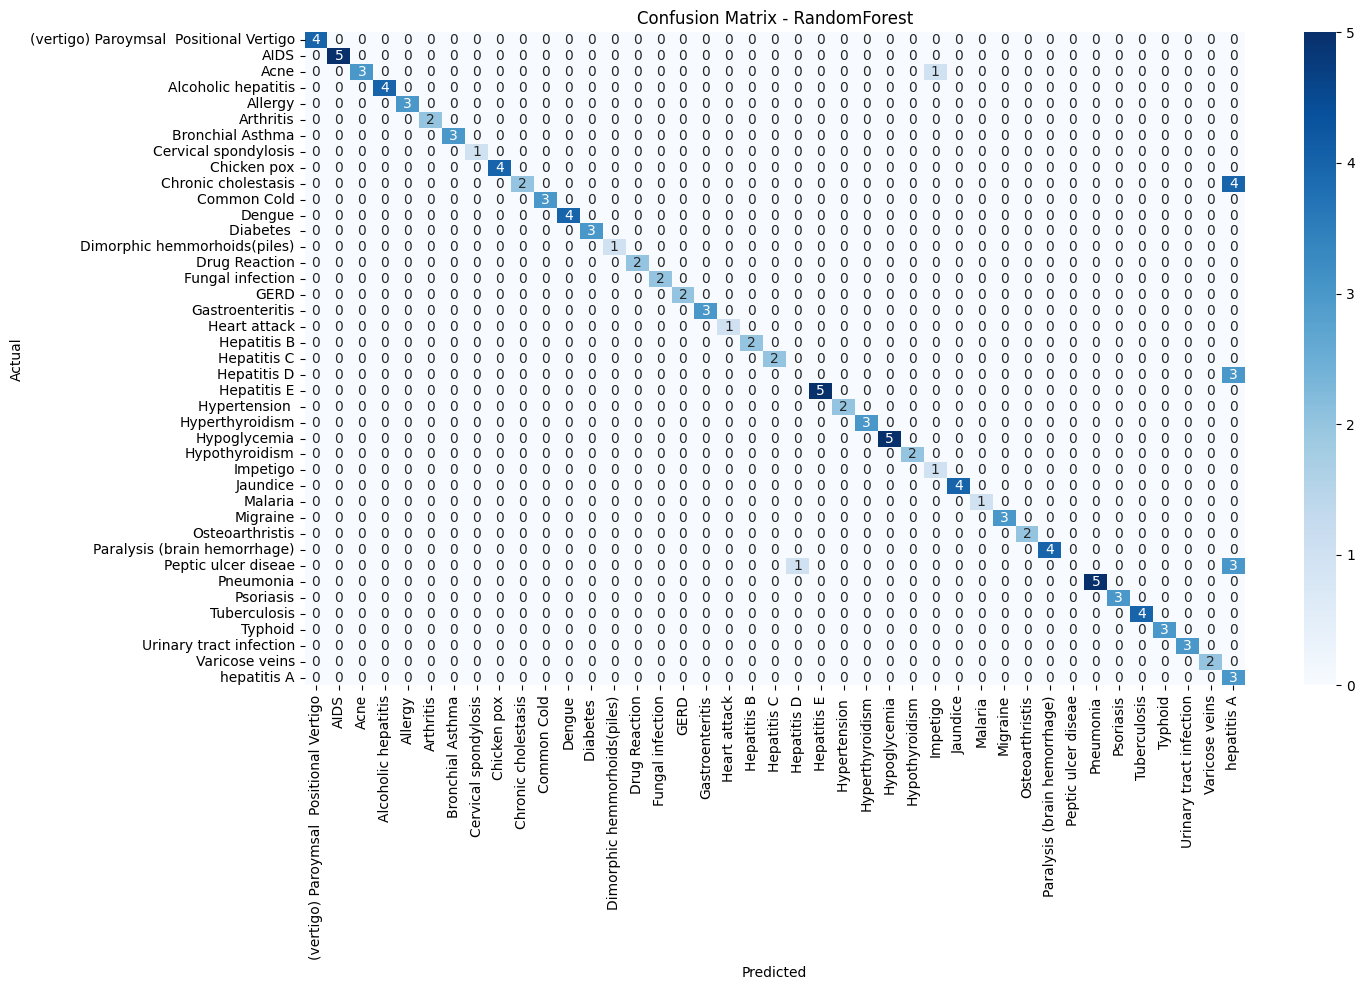

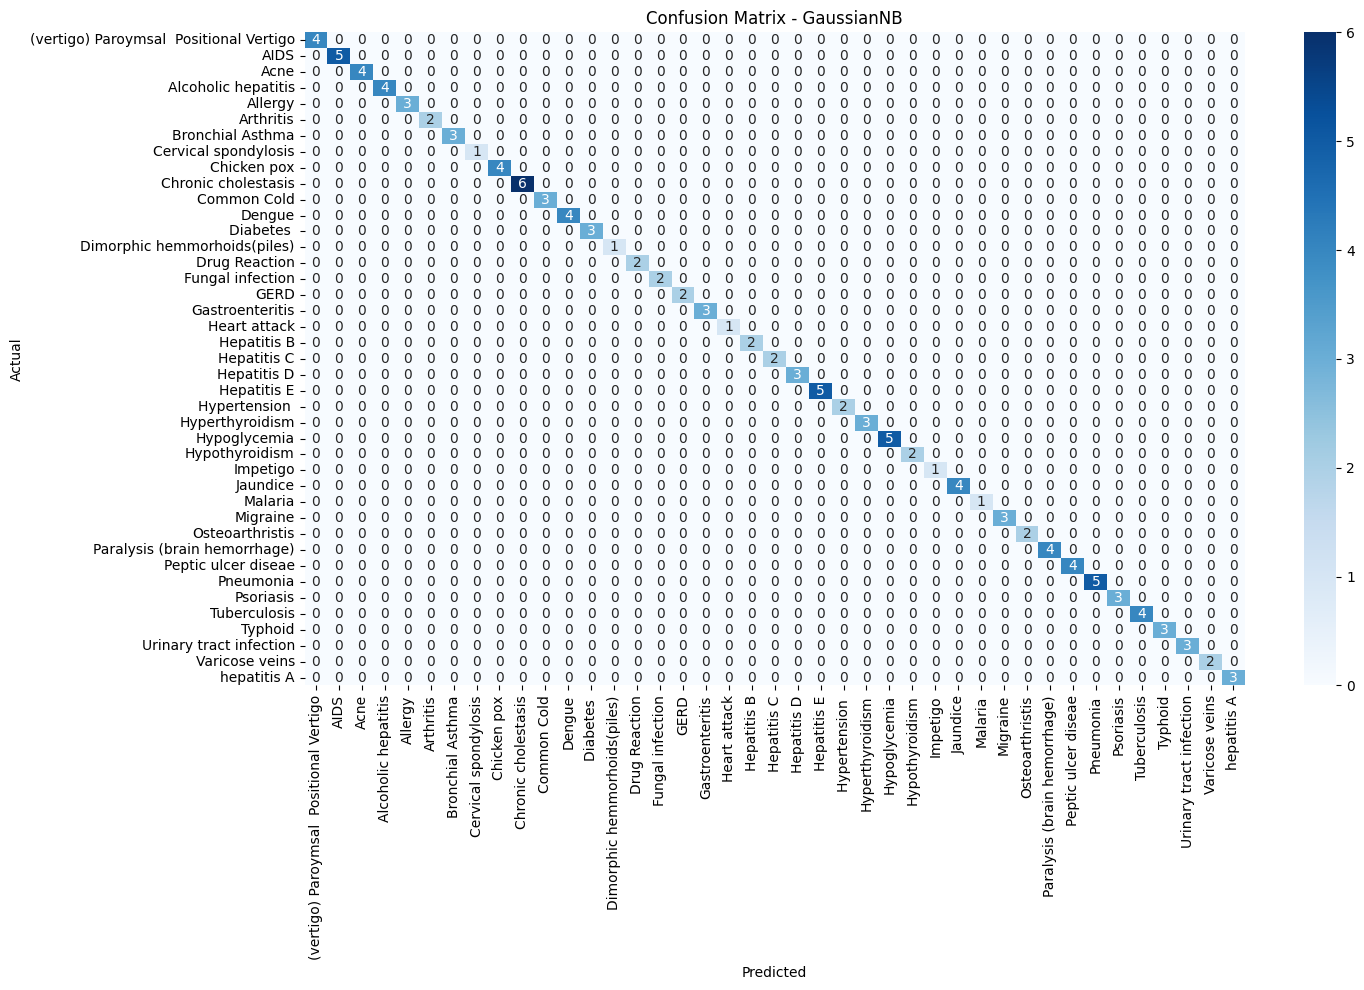

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
df = pd.read_csv("deasease.csv")

# Optional: View basic info
# print(df.info())
# print(df.isnull().sum())

# Balance the dataset: Sample equal number of rows per class
desired_rows_per_class = 10
df = df.groupby('prognosis').apply(lambda x: x.sample(desired_rows_per_class, random_state=42)).reset_index(drop=True)

# Features and target
X = df.drop('prognosis', axis=1)
y = df['prognosis']

# Encode target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=20)

# Define models
models = {
    'SVC': SVC(kernel='linear', C=1),
    'RandomForest': RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42),
    'GaussianNB': GaussianNB()
}

# Store results
accuracies = {}
conf_matrices = {}

# Train, predict, evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    
    acc = accuracy_score(y_test, predictions)
    cm = confusion_matrix(y_test, predictions)
    
    accuracies[name] = acc
    conf_matrices[name] = cm
    
    print(f"Model: {name}")
    print(f"Accuracy: {acc:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, predictions, target_names=le.classes_))
    print("="*50)

# Plot accuracies
plt.figure(figsize=(8, 5))
sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()))
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

# Plot confusion matrices
for name, cm in conf_matrices.items():
    plt.figure(figsize=(15, 10))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=le.classes_,
                yticklabels=le.classes_)
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()